# **Data preparation**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score
import matplotlib.pyplot as plt
from tpot import TPOTRegressor
from sklearn.model_selection import train_test_split

In [3]:
train_file_path = "/kaggle/input/house-prices-advanced-regression-techniques/train.csv"
test_file_path = "/kaggle/input/house-prices-advanced-regression-techniques/test.csv"
wb = pd.read_csv(train_file_path)
ws_test  = pd.read_csv(test_file_path)

In [4]:
wb.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [5]:
ws_test.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [6]:
start_id= ws_test['Id'].min()
start_id

1461

we have to predict prices from id = 1461

In [7]:
list(set(wb.dtypes.tolist()))

[dtype('O'), dtype('int64'), dtype('float64')]

In [8]:
len(wb.columns)

81

In [9]:
list(set(ws_test.dtypes.tolist()))

[dtype('O'), dtype('int64'), dtype('float64')]

In [10]:
len(ws_test.columns)

80

wb has 81 column and ws_test 80; the structures of the databases are globally identical and can be used for machine learning. We will define a function to transform qualitative variables into quantitative variables

In [11]:
def process_dataframe(wb):
    df_final = wb.copy()
    for col in wb.columns:
        if wb[col].dtype == 'object':          
            dummies = pd.get_dummies(wb[col], prefix=col, dummy_na=True)           
            df_final = pd.concat([df_final, dummies], axis=1)
    df_final.drop(wb.select_dtypes(include=['object']).columns, axis=1, inplace=True)
    if 'Id' in df_final.columns:
        df_final = df_final.drop(['Id'], axis=1)
    return df_final

In [12]:
wb =  process_dataframe(wb)
ws_test =  process_dataframe(ws_test )

In [13]:
len(wb.columns)

331

In [14]:
len(ws_test.columns)

312

In [15]:
columns_ws_test = ws_test.columns
columns_to_keep = [col for col in columns_ws_test if col in wb.columns]  
if 'SalePrice' in wb.columns:  
    columns_to_keep.append('SalePrice')  
wb = wb[columns_to_keep]

In [16]:
len(wb.columns)

313

wb has 313 column and ws_test 312; the structures of the databases are globally identical and can be used for machine learning

# **Statistical study of the data**

In [17]:
wb.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


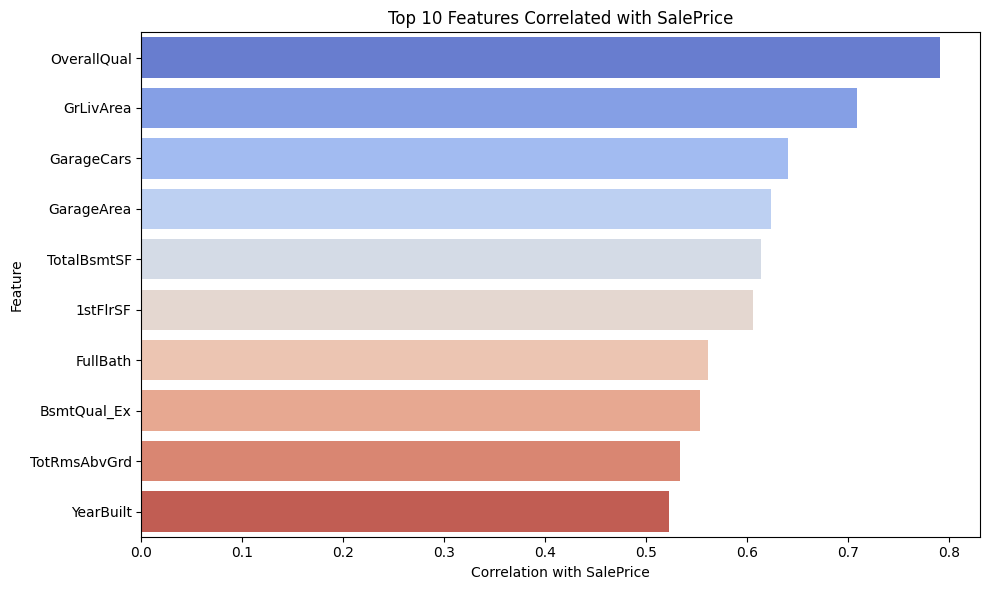

In [18]:
correlation = wb.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
top_corr = correlation.drop('SalePrice').head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title("Top 10 Features Correlated with SalePrice")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

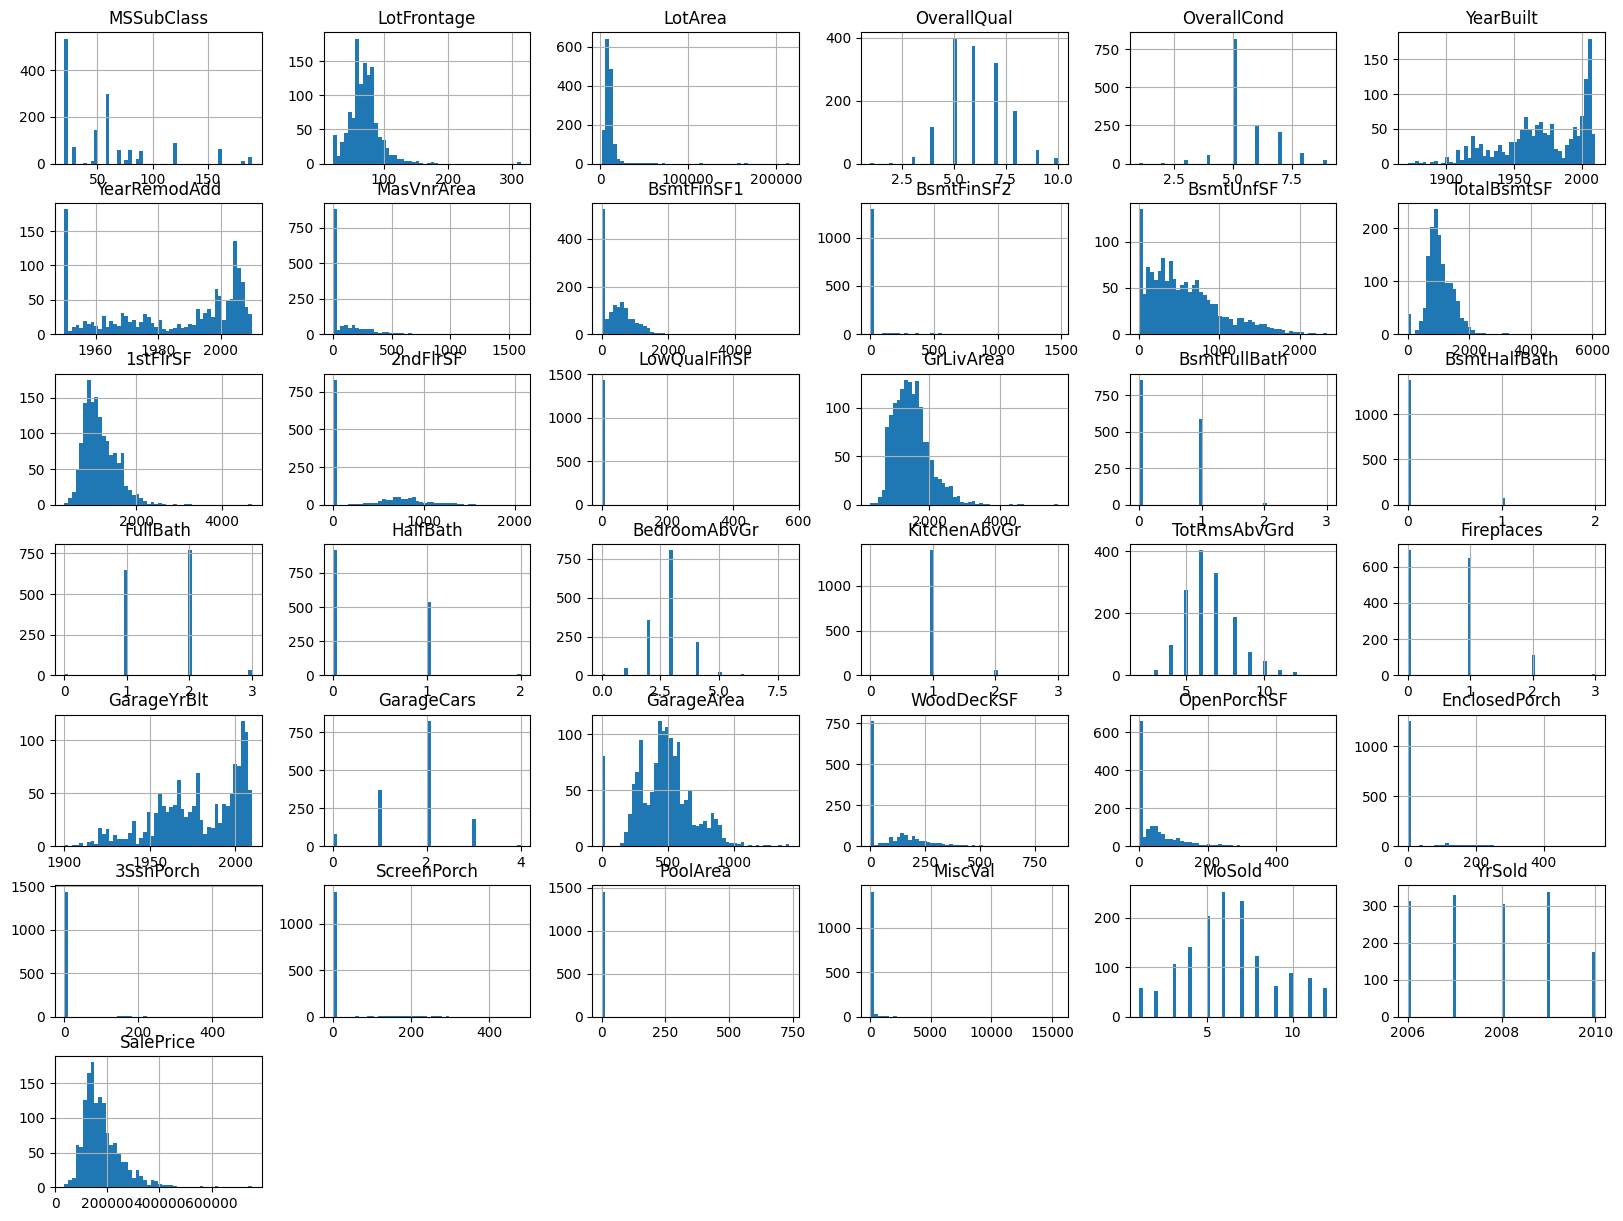

In [19]:
wb.hist(bins=50, figsize=(20,15))
# creates a figure with 10 (width) x 5 (height) inches
plt.rcParams['figure.figsize'] = [10, 5]
plt.show()

In [20]:
#descriptive statistics summary
wb['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

/tmp/ipykernel_13/286179593.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(wb['SalePrice']);
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


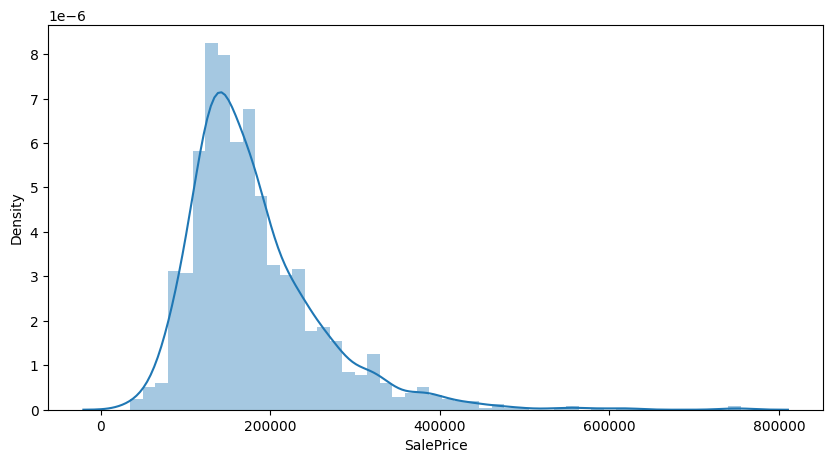

In [21]:
#SalePrice
sns.distplot(wb['SalePrice']);

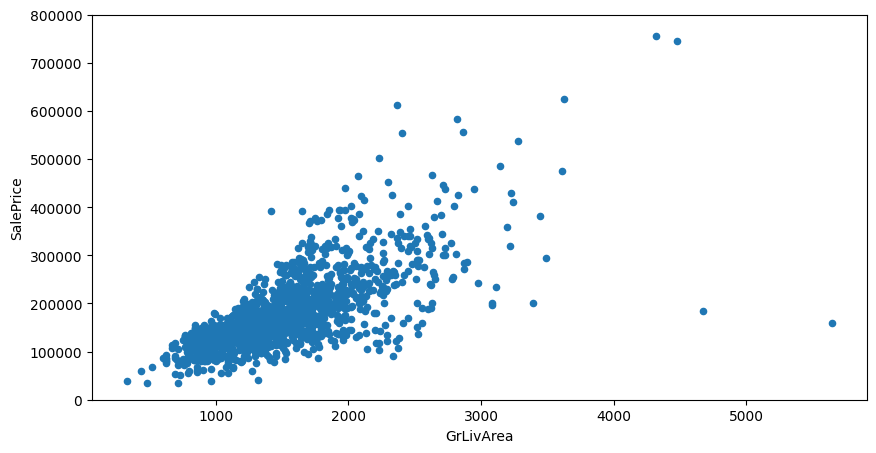

In [22]:
var = 'GrLivArea'
data = pd.concat([wb['SalePrice'], wb[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000));

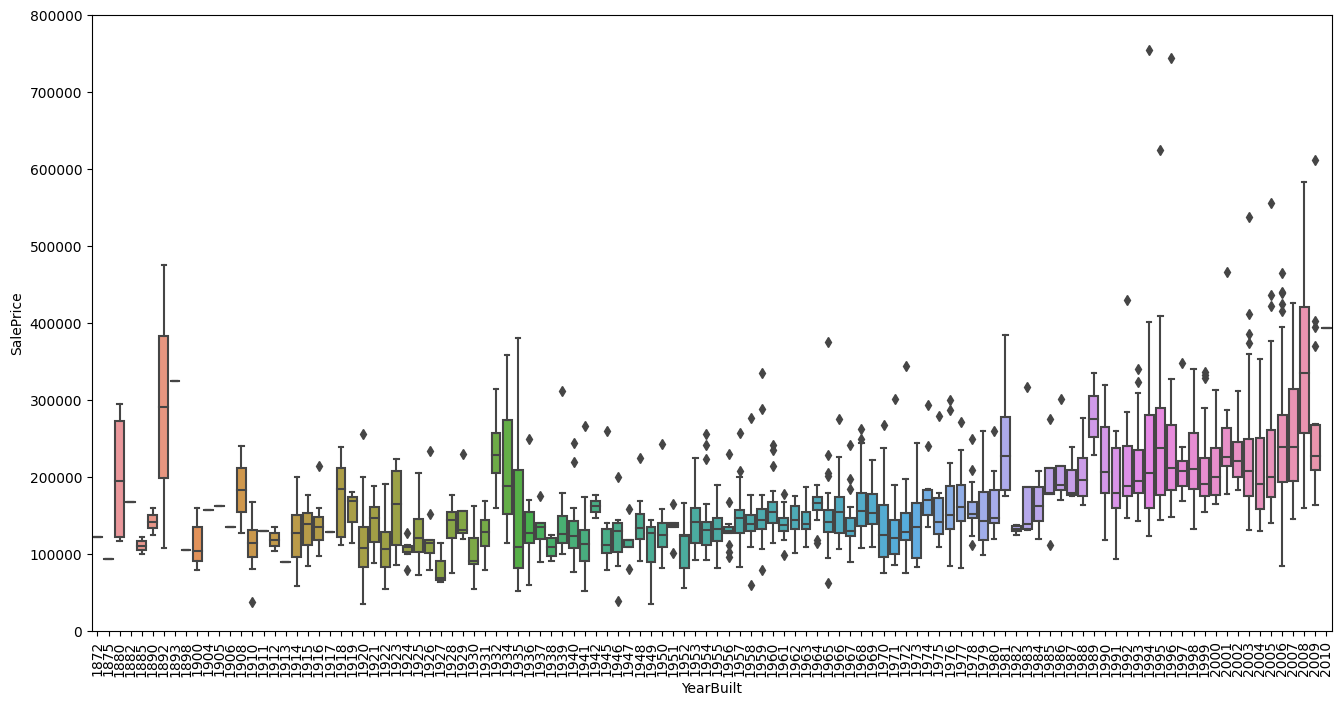

In [23]:
var = 'YearBuilt'
data = pd.concat([wb['SalePrice'], wb[var]], axis=1)
f, ax = plt.subplots(figsize=(16, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);
plt.xticks(rotation=90);

# **Application of the tpot process**

In [24]:
X_features = wb.drop(['SalePrice'], axis=1)
y_target= wb['SalePrice']

In [25]:
#EVALUATION AVEC mse
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.25)
reg = TPOTRegressor(verbosity=2, population_size=50, generations=20, random_state=35, scoring='neg_mean_squared_error')
reg.fit(X_train, y_train)
print(reg.score(X_test, y_test))
#reg.export('top_kaggle.py')

Imputing missing values in feature set


Optimization Progress:   0%|          | 0/1050 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: -907352079.7703998

Generation 2 - Current best internal CV score: -907352079.7703998

Generation 3 - Current best internal CV score: -907352079.7703998

Generation 4 - Current best internal CV score: -897976540.0887867

Generation 5 - Current best internal CV score: -895490001.4565868

Generation 6 - Current best internal CV score: -886873925.5665092

Generation 7 - Current best internal CV score: -878312544.4877075

Generation 8 - Current best internal CV score: -878312544.4877075

Generation 9 - Current best internal CV score: -865070951.9334526

Generation 10 - Current best internal CV score: -865070951.9334526

Generation 11 - Current best internal CV score: -837689803.3086188

Generation 12 - Current best internal CV score: -837689803.3086188

Generation 13 - Current best internal CV score: -837689803.3086188

Generation 14 - Current best internal CV score: -837689803.3086188

Generation 15 - Current best internal CV score: -8376898

In [26]:
#Stages of the best pipeline
print('\nStages of the best pipeline:', end='\n')
for idx, (name, transform) in enumerate(reg.fitted_pipeline_.steps, start=1):
    print(f'{idx}. {transform}')


Stages of the best pipeline:
1. FeatureUnion(transformer_list=[('stackingestimator-1',
                                StackingEstimator(estimator=LassoLarsCV(normalize=False))),
                               ('stackingestimator-2',
                                StackingEstimator(estimator=XGBRegressor(base_score=None,
                                                                         booster=None,
                                                                         callbacks=None,
                                                                         colsample_bylevel=None,
                                                                         colsample_bynode=None,
                                                                         colsample_bytree=None,
                                                                         device=None,
                                                                         early_stopping_rounds=None,
                       

We can even see all the models that tpot has tested with the score

In [27]:
my_dict = list(reg.evaluated_individuals_.items())
my_dict

[('KNeighborsRegressor(XGBRegressor(input_matrix, XGBRegressor__learning_rate=0.5, XGBRegressor__max_depth=2, XGBRegressor__min_child_weight=6, XGBRegressor__n_estimators=100, XGBRegressor__n_jobs=1, XGBRegressor__objective=reg:squarederror, XGBRegressor__subsample=0.9500000000000001, XGBRegressor__verbosity=0), KNeighborsRegressor__n_neighbors=82, KNeighborsRegressor__p=1, KNeighborsRegressor__weights=distance)',
  {'generation': 0,
   'mutation_count': 0,
   'crossover_count': 0,
   'predecessor': ('ROOT',),
   'operator_count': 2,
   'internal_cv_score': -1080612748.0046003}),
 ('GradientBoostingRegressor(input_matrix, GradientBoostingRegressor__alpha=0.8, GradientBoostingRegressor__learning_rate=0.001, GradientBoostingRegressor__loss=quantile, GradientBoostingRegressor__max_depth=5, GradientBoostingRegressor__max_features=0.7000000000000001, GradientBoostingRegressor__min_samples_leaf=9, GradientBoostingRegressor__min_samples_split=17, GradientBoostingRegressor__n_estimators=100, G

In [28]:
#see just a few
models_tested  = pd.DataFrame(reg.evaluated_individuals_).transpose()
models_tested.sort_values(['internal_cv_score'], ascending=False)[3:6]

,generation,mutation_count,crossover_count,predecessor,operator_count,internal_cv_score
"RandomForestRegressor(SelectFwe(MaxAbsScaler(LassoLarsCV(input_matrix, LassoLarsCV__normalize=False)), SelectFwe__alpha=0.032), RandomForestRegressor__bootstrap=False, RandomForestRegressor__max_features=0.3, RandomForestRegressor__min_samples_leaf=3, RandomForestRegressor__min_samples_split=14, RandomForestRegressor__n_estimators=100)",19,22,7,(RandomForestRegressor(SelectFwe(LassoLarsCV(i...,4,-829149288.58265
"RandomForestRegressor(SelectFwe(VarianceThreshold(LassoLarsCV(input_matrix, LassoLarsCV__normalize=False), VarianceThreshold__threshold=0.05), SelectFwe__alpha=0.032), RandomForestRegressor__bootstrap=False, RandomForestRegressor__max_features=0.3, RandomForestRegressor__min_samples_leaf=3, RandomForestRegressor__min_samples_split=14, RandomForestRegressor__n_estimators=100)",19,22,7,(RandomForestRegressor(SelectFwe(LassoLarsCV(i...,4,-831002370.049149
"RandomForestRegressor(AdaBoostRegressor(StandardScaler(ExtraTreesRegressor(LassoLarsCV(input_matrix, LassoLarsCV__normalize=False), ExtraTreesRegressor__bootstrap=False, ExtraTreesRegressor__max_features=0.7500000000000001, ExtraTreesRegressor__min_samples_leaf=14, ExtraTreesRegressor__min_samples_split=13, ExtraTreesRegressor__n_estimators=100)), AdaBoostRegressor__learning_rate=1.0, AdaBoostRegressor__loss=square, AdaBoostRegressor__n_estimators=100), RandomForestRegressor__bootstrap=False, RandomForestRegressor__max_features=0.3, RandomForestRegressor__min_samples_leaf=13, RandomForestRegressor__min_samples_split=9, RandomForestRegressor__n_estimators=100)",18,6,0,(RandomForestRegressor(StandardScaler(ExtraTre...,5,-831143802.677332


In [29]:
#Topt can write us the code of the best model
#reg.export('top_kaggle.py')

# **TRAINING**

the code can be found at the following address: top_kaggle.py that tpot has generated for us

In [30]:
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, make_union
from tpot.builtins import StackingEstimator
from sklearn.impute import SimpleImputer
from tpot.export_utils import set_param_recursive

In [31]:
training_features = X_features 
training_target= y_target
imputer = SimpleImputer(strategy="median")
imputer.fit(training_features)
training_features = imputer.transform(training_features)
# Average CV score on the training set was: -667355173.6156621
exported_pipeline = make_pipeline(
    StackingEstimator(estimator=RidgeCV()),
    SelectPercentile(score_func=f_regression, percentile=65),
    StackingEstimator(estimator=RidgeCV()),
    StackingEstimator(estimator=RidgeCV()),
    ExtraTreesRegressor(bootstrap=True, max_features=1.0, min_samples_leaf=2, min_samples_split=12, n_estimators=100)
)
# Fix random state for all the steps in exported pipeline
set_param_recursive(exported_pipeline.steps, 'random_state', 35)
exported_pipeline.fit(training_features, training_target)

Pipeline(steps=[('stackingestimator-1', StackingEstimator(estimator=RidgeCV())),
                ('selectpercentile',
                 SelectPercentile(percentile=65,
                                  score_func=<function f_regression at 0x7c52ad8c1940>)),
                ('stackingestimator-2', StackingEstimator(estimator=RidgeCV())),
                ('stackingestimator-3', StackingEstimator(estimator=RidgeCV())),
                ('extratreesregressor',
                 ExtraTreesRegressor(bootstrap=True, min_samples_leaf=2,
                                     min_samples_split=12, random_state=35))])

# **Validation of the model**

In [32]:
predictions = exported_pipeline.predict(training_features)
n_eval = min(len(predictions), len(training_target))
mse = mean_squared_error(training_target[:n_eval], predictions[:n_eval])
r2 = r2_score(training_target[:n_eval], predictions[:n_eval])
results = {"MSE": mse, "R2": r2, "Predictions": predictions}
df_actual = pd.DataFrame(training_target[:n_eval], columns=["SalePrice"])
df_pred = pd.DataFrame(predictions[:n_eval], columns=["Predit"])
desc_actual = df_actual["SalePrice"].describe()
desc_pred = df_pred["Predit"].describe()
stats_df = pd.concat([desc_actual, desc_pred], axis=1)
stats_df.columns = ["Current statistics", "Predicted statistics"]
print(stats_df)

       Current statistics  Predicted statistics
count         1460.000000           1460.000000
mean        180921.195890         180996.517339
std          79442.502883          75829.867849
min          34900.000000          57070.939186
25%         129975.000000         130697.081660
50%         163000.000000         163585.167877
75%         214000.000000         214390.560522
max         755000.000000         611064.276133


In [33]:
error = df_pred['Predit'] -  df_actual['SalePrice']

In [34]:
error.describe()

count      1460.000000
mean         75.321449
std       15426.657559
min     -148841.417829
25%       -5254.087260
50%          16.379357
75%        5750.103725
max      193379.943232
dtype: float64

In [35]:
import scipy.stats as st
skewness = st.skew(error)
print(f"Skewness : {skewness}")
kurtosis = st.kurtosis(error)
print(f"Kurtosis : {kurtosis}")

Skewness : 0.3361744043565676
Kurtosis : 34.99603082217161


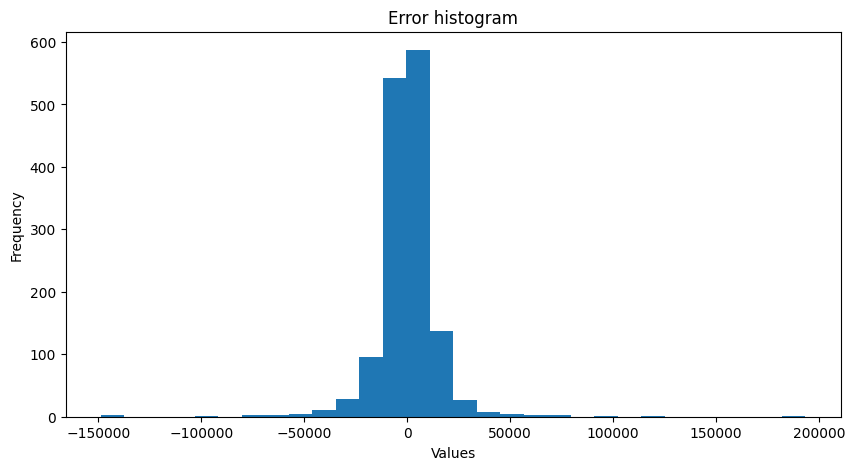

In [36]:
plt.hist(error, bins=30)
plt.title("Error histogram")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

Statistique de Jarque-Bera: 74531.4320954736
p-value: 0.0
Rejection of the null hypothesis: the data are not normally distributed.


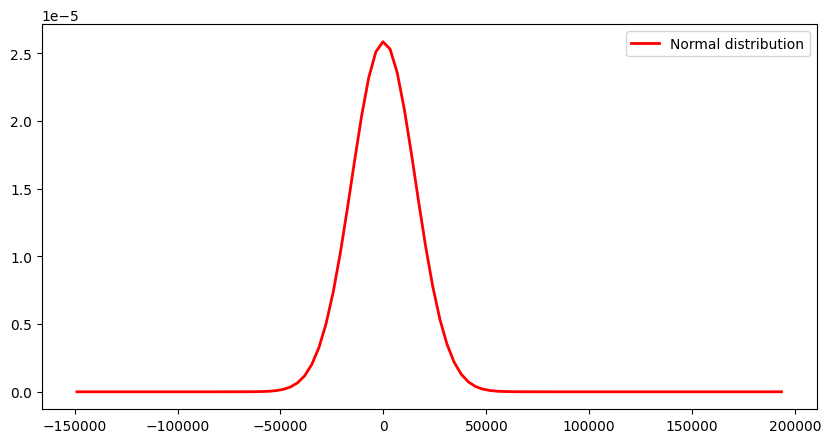

In [37]:
# Perform the Jarque-Bera test
from scipy.stats import jarque_bera
from scipy.stats import norm
jb_test = jarque_bera(error)
print("Statistique de Jarque-Bera:", jb_test[0])
print("p-value:", jb_test[1])
alpha = 0.05
if jb_test[1] < alpha:
    print("Rejection of the null hypothesis: the data are not normally distributed.")
else:
    print("Non rejection of the null hypothesis: the data could be normally distributed.")

x = np.linspace(error.min(), error.max(), 100)
plt.plot(x, norm.pdf(x, error.mean(), error.std()), 'r-', lw=2, label='Normal distribution')
plt.legend()
plt.show()

# **Forecasts**

In [38]:
testing_features  = ws_test 
imputer = SimpleImputer(strategy="median")
imputer.fit(testing_features)
testing_features = imputer.transform(testing_features)
results = exported_pipeline.predict(testing_features)

In [39]:
results = pd.DataFrame({'SalePrice': results})

In [40]:
results

,SalePrice
0,118743.091334
1,149569.909762
2,175982.503252
3,185432.680257
4,200596.599437
...,...
1454,83470.800807
1455,87417.024141
1456,150407.945139
1457,102686.954627


In [41]:
results.to_csv('//kaggle/working//submission.csv', index=False)